### Análisis Exploratorio de Datos (EDA)

Este notebook realiza un análisis exploratorio del **corpus anonimizado** utilizado en la investigación, siguiendo la fase **"Data Understanding"** de la metodología CRISP-DM.  
El objetivo es caracterizar estadísticamente el conjunto de datos, identificar patrones léxicos por categoría, evaluar la calidad del texto, y cuantificar las diferencias y similitudes entre categorías.

Todos los análisis se basan en la columna `text_anon`, garantizando el cumplimiento del requisito funcional **RF4** (protección de datos sensibles).

In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Para pruebas estadísticas y similitud léxica
from scipy.stats import kruskal
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
pd.set_option('display.max_colwidth', 100)

# Cargar corpus anonimizado
df = pd.read_csv("data/corpus_anon.csv")
print(f"✅ Cargados {len(df)} documentos anonimizados.")

✅ Cargados 906 documentos anonimizados.


### Distribución de documentos por categoría

Esta sección muestra la frecuencia absoluta de documentos en cada una de las seis categorías definidas en la Tabla 3 (p. 55) de la tesis. Esta distribución es fundamental para:
- Evaluar el balance del corpus.
- Diseñar la partición estratificada.
- Interpretar métricas de clasificación (uso de F1 macro en lugar de accuracy).

Distribución por categoría:
category
Contratos                         155
Correos electrónicos              158
Correspondencia administrativa    146
Cotizaciones                      139
Documentos fiscales               158
Recursos Humanos                  150
Name: count, dtype: int64


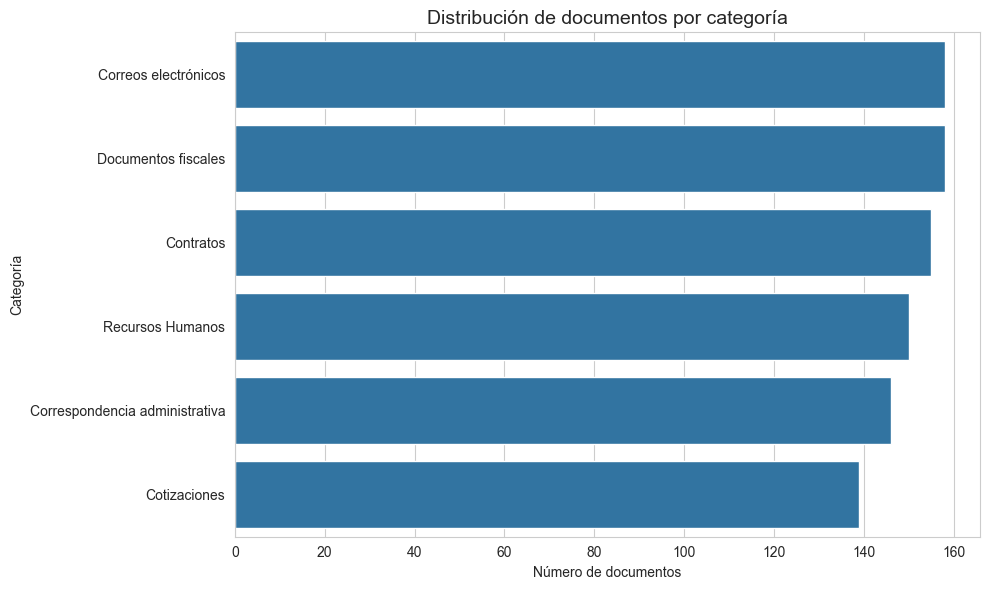

In [2]:
# Mostrar conteo
print("Distribución por categoría:")
print(df["category"].value_counts().sort_index())

# Gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
ax.set_title("Distribución de documentos por categoría", fontsize=14)
ax.set_xlabel("Número de documentos")
ax.set_ylabel("Categoría")
plt.tight_layout()
plt.show()

### Longitud de los documentos y diferencias estadísticas entre categorías

La longitud (en palabras) de los documentos afecta directamente el desempeño de los modelos de PLN. Aquí se analiza:
- La distribución global y por categoría.
- Si existen diferencias **estadísticamente significativas** en la longitud mediana entre categorías.

Dado que la longitud no sigue una distribución normal (sesgo positivo), se utiliza la **prueba no paramétrica de Kruskal-Wallis**, válida para comparar medianas en >2 grupos sin supuestos de normalidad.

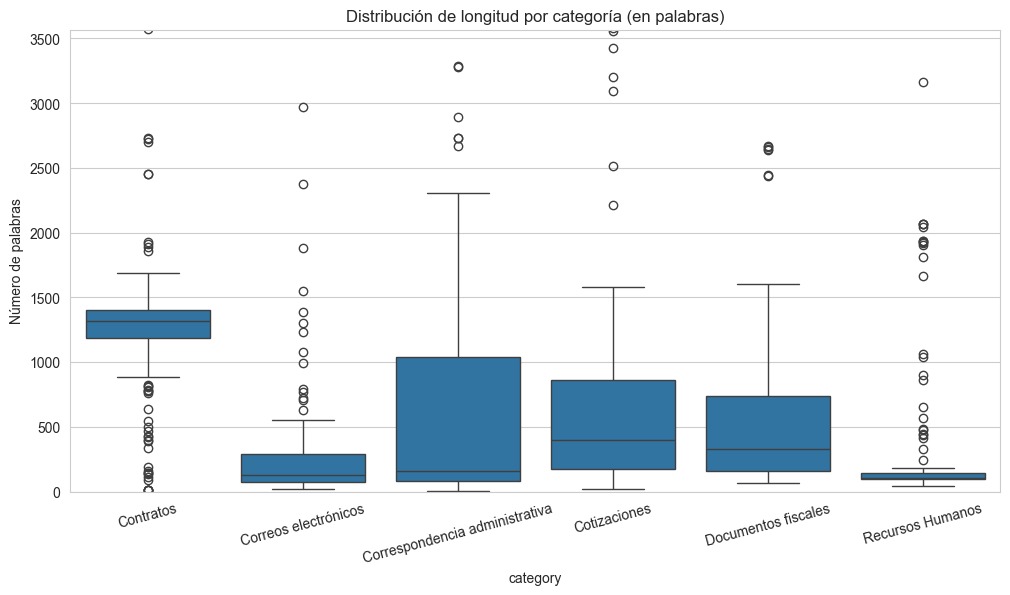


📊 Resultados de la prueba de Kruskal-Wallis:
Estadístico H = 278.530
p-valor = 4.12e-58
✅ Conclusión: Existen diferencias estadísticamente significativas en la longitud mediana entre al menos dos categorías.


In [3]:
# Calcular longitud en palabras
df["word_len"] = df["text_anon"].str.split().str.len()

# Boxplot por categoría
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="category", y="word_len")
plt.title("Distribución de longitud por categoría (en palabras)")
plt.xticks(rotation=15)
plt.ylabel("Número de palabras")
plt.ylim(0, df["word_len"].quantile(0.95))  # eliminar outliers extremos
plt.show()

# Prueba de Kruskal-Wallis
groups = [df[df["category"] == cat]["word_len"] for cat in df["category"].unique()]
stat, p_value = kruskal(*groups)

print(f"\n📊 Resultados de la prueba de Kruskal-Wallis:")
print(f"Estadístico H = {stat:.3f}")
print(f"p-valor = {p_value:.2e}")

if p_value < 0.05:
    print("✅ Conclusión: Existen diferencias estadísticamente significativas en la longitud mediana entre al menos dos categorías.")
else:
    print("⚠️ Conclusión: No se detectaron diferencias significativas en longitud entre categorías.")

### Similitud léxica entre categorías

Para anticipar posibles errores de clasificación, se mide la **similitud léxica promedio** entre documentos de diferentes categorías.  
Se utiliza:
- **TF-IDF** con n-gramas (1-2) para capturar tanto palabras como frases comunes.
- **Similitud coseno promedio** entre todos los pares de documentos de dos categorías.

Un valor alto de similitud entre dos categorías distintas sugiere que el clasificador podría confundirlas, lo cual debe verificarse en la matriz de confusión posterior.

Generando representación TF-IDF para análisis de similitud...


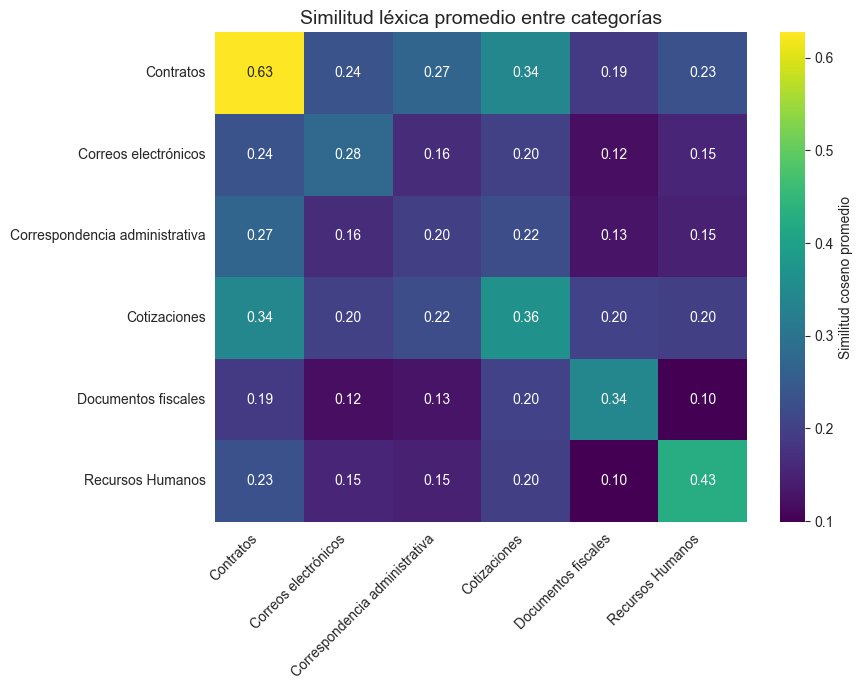


🔍 Par de categorías con mayor similitud léxica:
  → 'Contratos' y 'Cotizaciones' (similitud = 0.34)
Esto indica un posible desafío para el modelo de clasificación.


In [4]:
# Vectorización TF-IDF
print("Generando representación TF-IDF para análisis de similitud...")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["text_anon"])

# Calcular matriz de similitud promedio entre categorías
categories = sorted(df["category"].unique())
n_cats = len(categories)
similarity_matrix = np.zeros((n_cats, n_cats))

for i, cat_i in enumerate(categories):
    for j, cat_j in enumerate(categories):
        idx_i = df[df["category"] == cat_i].index
        idx_j = df[df["category"] == cat_j].index
        sim = cosine_similarity(X_tfidf[idx_i], X_tfidf[idx_j]).mean()
        similarity_matrix[i, j] = sim

# Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    similarity_matrix,
    xticklabels=categories,
    yticklabels=categories,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={'label': 'Similitud coseno promedio'}
)
plt.title("Similitud léxica promedio entre categorías", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Encontrar par con mayor similitud (fuera de la diagonal)
max_sim = 0
pair = ("", "")
for i in range(n_cats):
    for j in range(i + 1, n_cats):
        if similarity_matrix[i, j] > max_sim:
            max_sim = similarity_matrix[i, j]
            pair = (categories[i], categories[j])

print(f"\n🔍 Par de categorías con mayor similitud léxica:")
print(f"  → '{pair[0]}' y '{pair[1]}' (similitud = {max_sim:.2f})")
print("Esto indica un posible desafío para el modelo de clasificación.")

### Palabras más frecuentes por categoría

Este análisis revela los términos léxicos dominantes en cada categoría, lo que ayuda a:
- Validar que el corpus captura el dominio esperado.
- Identificar posibles palabras clave para reglas heurísticas.
- Detectar fugas de datos (ej. si "[MONTO]" aparece solo en una categoría).

Se excluyen palabras de menos de 2 caracteres y se usan expresiones regulares para preservar acentos y ñ.

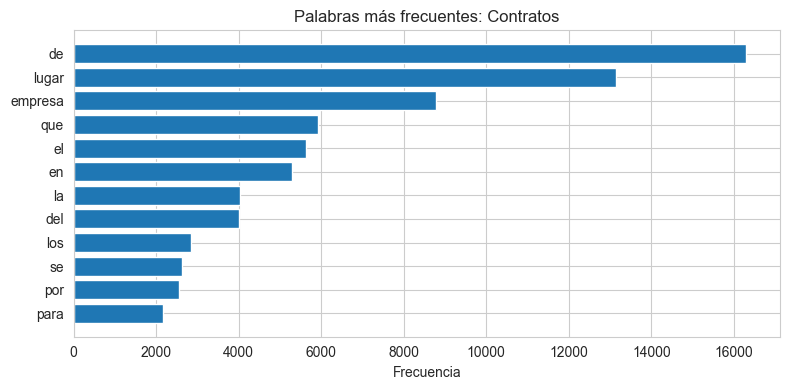

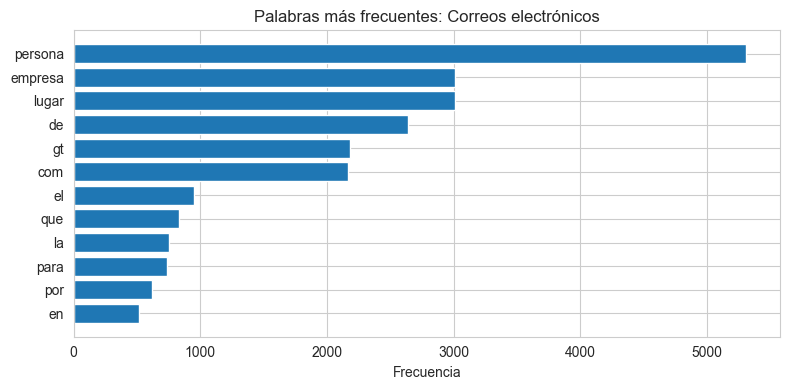

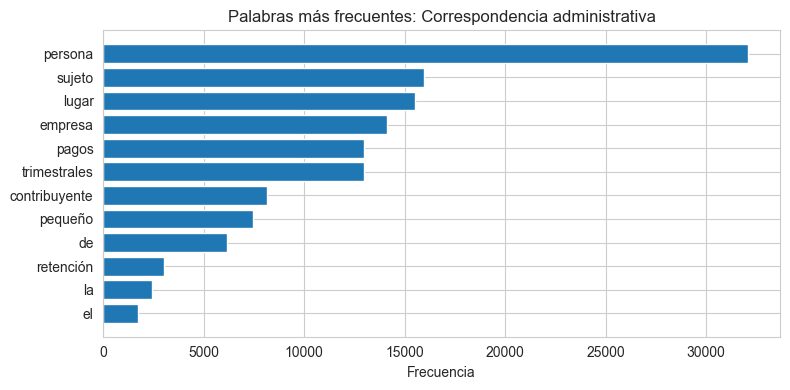

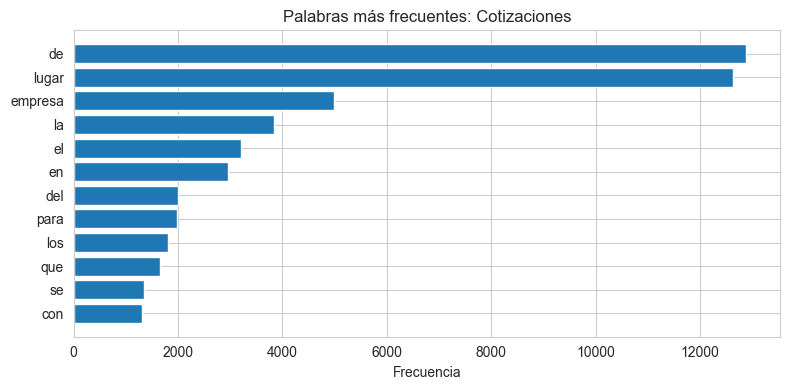

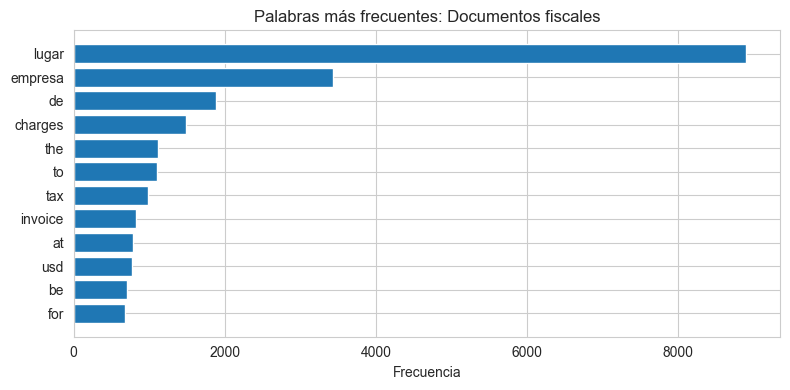

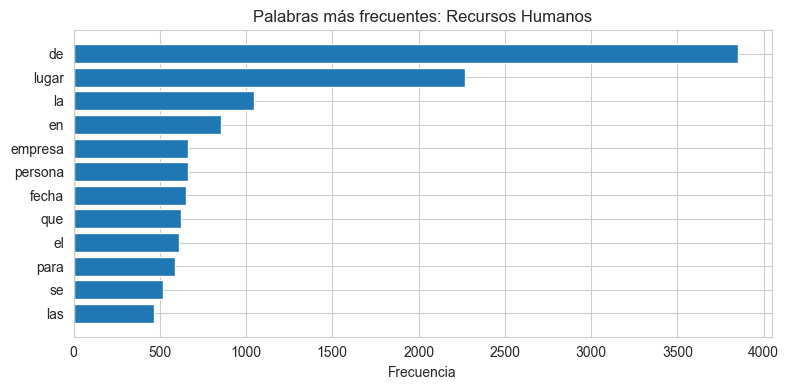

In [5]:
def get_top_words(texts, n=12):
    all_text = " ".join(texts)
    words = re.findall(r'\b[a-zA-ZáéíóúñÁÉÍÓÚÑ]{2,}\b', all_text.lower())
    return Counter(words).most_common(n)

for cat in sorted(df["category"].unique()):
    subset = df[df["category"] == cat]["text_anon"]
    top_words = get_top_words(subset, n=12)
    if not top_words:
        continue
    words, counts = zip(*top_words)
    
    plt.figure(figsize=(8, 4))
    plt.barh(words[::-1], counts[::-1])
    plt.title(f"Palabras más frecuentes: {cat}")
    plt.xlabel("Frecuencia")
    plt.tight_layout()
    plt.show()

### Diversidad léxica y efectividad de la anonimización

Se calculan dos métricas clave:
1. **Índice de Tipo-Token (TTR)**: mide la riqueza léxica (palabras únicas / total). Valores bajos indican textos repetitivos (ej. formularios).
2. **Conteo de marcadores de anonimización**: valida que el proceso de anonimización se aplicó y cuantifica la presencia original de datos sensibles.

Estas métricas refuerzan el cumplimiento del requisito **RF4** y caracterizan la naturaleza del corpus.

In [6]:
# Calcular TTR
def ttr(text):
    words = re.findall(r'\b\w+\b', text.lower())
    return len(set(words)) / len(words) if words else 0

df["ttr"] = df["text_anon"].apply(ttr)

# TTR promedio por categoría
print("Diversidad léxica promedio (TTR) por categoría:")
ttr_summary = df.groupby("category")["ttr"].mean().sort_values(ascending=False)
print(ttr_summary.round(4))
print()

# Conteo de marcadores de anonimización
markers = ["[PERSONA]", "[EMPRESA]", "[MONTO]", "[FECHA]", "[LUGAR]"]
print("Total de marcadores de anonimización en el corpus:")
for marker in markers:
    total = df["text_anon"].str.count(marker).sum()
    print(f"  {marker}: {int(total):,}")

Diversidad léxica promedio (TTR) por categoría:
category
Recursos Humanos                  0.5775
Correos electrónicos              0.5550
Correspondencia administrativa    0.5079
Cotizaciones                      0.5042
Contratos                         0.4268
Documentos fiscales               0.4017
Name: ttr, dtype: float64

Total de marcadores de anonimización en el corpus:
  [PERSONA]: 793,507
  [EMPRESA]: 713,120
  [MONTO]: 191,602
  [FECHA]: 353,831
  [LUGAR]: 507,035


### Resumen del análisis exploratorio

Se genera un resumen estadístico que puede incluirse en el Capítulo 4 de la tesis. Este resumen contiene:
- Número total de documentos por categoría.
- Longitud promedio y mediana.
- Diversidad léxica (TTR).

El archivo `eda_summary.csv` se guarda en la carpeta `results/` para uso posterior.

In [7]:
# Resumen estadístico
summary = df.groupby("category").agg(
    total_docs=("text_anon", "count"),
    avg_words=("word_len", "mean"),
    median_words=("word_len", "median"),
    ttr_avg=("ttr", "mean")
).round(3)

# Guardar
summary.to_csv("results/eda_summary.csv")
print("Resumen guardado en 'results/eda_summary.csv'")
summary

Resumen guardado en 'results/eda_summary.csv'


,total_docs,avg_words,median_words,ttr_avg
category,,,,
Contratos,155,1590.948,1314.0,0.427
Correos electrónicos,158,363.392,130.0,0.555
Correspondencia administrativa,146,1803.130,156.5,0.508
Cotizaciones,139,1217.194,396.0,0.504
Documentos fiscales,158,509.348,327.5,0.402
Recursos Humanos,150,304.540,105.0,0.577
